# SVM Kernel Comparison

This notebook compares Support Vector Machine models with **linear** and **RBF** kernels on a binary classification dataset. The dataset predicts whether a student will pass or fail based on multiple features.

The notebook includes the required sections: Problem Statement, Understanding of Dataset, Theory, Mathematical Representation, Diagram, Pseudocode, Expected Output, and Obtained Output. It also includes simple data cleaning, EDA, feature scaling, and a direct comparison of both kernels.

In [1]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

DATA_PATH = 'svm_kernel_student_data.csv'
FEATURE_COLS = ['study_hours', 'attendance', 'sleep_hours']
TARGET_COL = 'result'

np.random.seed(42)
n = 240
study_hours = np.round(np.random.uniform(0, 12, n), 2)
attendance = np.round(np.random.uniform(40, 100, n), 2)
sleep_hours = np.round(np.random.uniform(4, 10, n), 2)

score = 0.55 * study_hours + 0.04 * attendance + 0.15 * sleep_hours + 0.8 * np.sin(study_hours / 2) + np.random.normal(0, 0.6, n)
result = (score >= 6.0).astype(int)

df_sample = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'sleep_hours': sleep_hours,
    TARGET_COL: result
})
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample.to_csv(DATA_PATH, index=False)

print(f'✓ Sample CSV created: {DATA_PATH} with {len(df_sample)} samples')
print(f'\nFirst 5 rows of {DATA_PATH}:')
print(df_sample.head())

✓ Sample CSV created: svm_kernel_student_data.csv with 240 samples

First 5 rows of svm_kernel_student_data.csv:
   study_hours  attendance  sleep_hours  result
0         5.47       92.64         8.11       1
1         0.70       65.69         4.27       0
2         6.74       46.96         7.73       0
3         0.92       77.55         4.91       0
4        10.89       63.91         7.80       1


## 1. Problem Statement

Build two SVM classifiers, one with a linear kernel and one with an RBF kernel, and compare their performance on the same binary classification problem.

## 2. Understanding of Dataset

Load the dataset and inspect the structure, labels, and summary statistics.

In [2]:
df = pd.read_csv(DATA_PATH)

print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print('\nFirst 10 rows:')
print(df.head(10))

print(f'\nDataset shape: {df.shape}')
print(f'Samples: {df.shape[0]}, Features: {df.shape[1]}')

print('\nColumn data types:')
print(df.dtypes)

print('\nStatistical Summary:')
print(df.describe().T)

print('\nClass Distribution:')
print(df[TARGET_COL].value_counts())

DATASET OVERVIEW

First 10 rows:
   study_hours  attendance  sleep_hours  result
0         5.47       92.64         8.11       1
1         0.70       65.69         4.27       0
2         6.74       46.96         7.73       0
3         0.92       77.55         4.91       0
4        10.89       63.91         7.80       1
5         6.15       97.04         7.52       1
6         5.91       93.47         6.47       1
7         8.76       73.26         6.35       1
8         8.50       91.18         9.34       1
9         3.61       92.65         6.91       1

Dataset shape: (240, 4)
Samples: 240, Features: 4

Column data types:
study_hours    float64
attendance     float64
sleep_hours    float64
result           int64
dtype: object

Statistical Summary:
             count       mean        std    min      25%     50%      75%  \
study_hours  240.0   5.763458   3.505290   0.06   2.7350   5.955   8.7425   
attendance   240.0  70.743083  18.333907  40.65  56.6625  71.770  86.8175   
sleep_hou

## 3. Data Cleaning

Check for missing values, duplicates, and invalid values.

In [3]:
print('='*60)
print('DATA CLEANING')
print('='*60)

print('\n1. Missing Values Check:')
missing = df.isnull().sum()
print(f'Missing values per column:\n{missing}')
if missing.sum() == 0:
    print('✓ No missing values found')
else:
    df = df.dropna()

print('\n2. Duplicate Rows Check:')
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'× Removed {dupes} duplicate(s)')
else:
    print('✓ No duplicates found')

print('\n3. Invalid Values Check:')
invalid_study = (df['study_hours'] < 0).sum()
invalid_attendance = ((df['attendance'] < 0) | (df['attendance'] > 100)).sum()
invalid_sleep = (df['sleep_hours'] < 0).sum()
invalid_target = (~df[TARGET_COL].isin([0, 1])).sum()
print(f'Invalid study hours: {invalid_study}')
print(f'Invalid attendance: {invalid_attendance}')
print(f'Invalid sleep hours: {invalid_sleep}')
print(f'Invalid target values: {invalid_target}')

df = df[(df['study_hours'] >= 0) & (df['attendance'] >= 0) & (df['attendance'] <= 100) & (df['sleep_hours'] >= 0)]
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)
print(f'\nDataset shape after cleaning: {df.shape}')

DATA CLEANING

1. Missing Values Check:
Missing values per column:
study_hours    0
attendance     0
sleep_hours    0
result         0
dtype: int64
✓ No missing values found

2. Duplicate Rows Check:
Duplicate rows: 0
✓ No duplicates found

3. Invalid Values Check:
Invalid study hours: 0
Invalid attendance: 0
Invalid sleep hours: 0
Invalid target values: 0

Dataset shape after cleaning: (240, 4)


## 4. Exploratory Data Analysis (EDA)

Visualize feature distributions and class separation.

EXPLORATORY DATA ANALYSIS


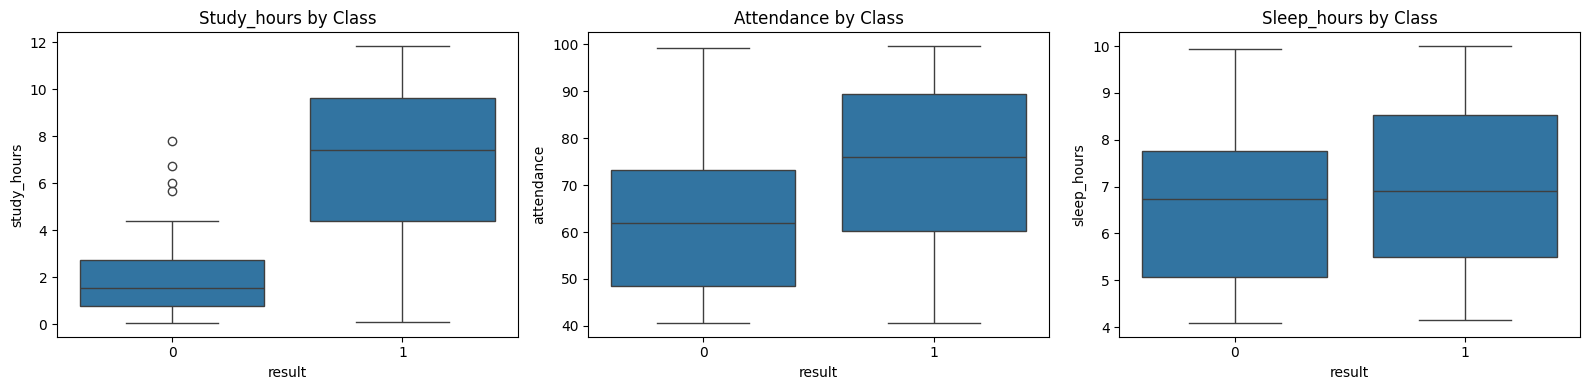

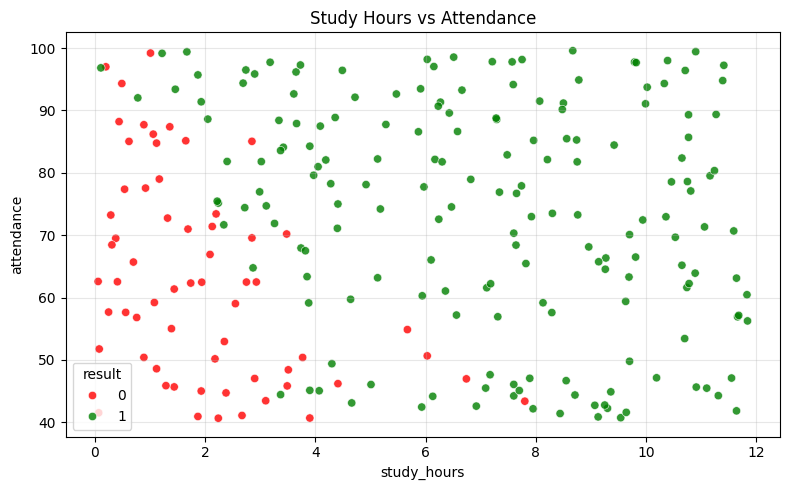


Correlation Matrix:
             study_hours  attendance  sleep_hours    result
study_hours     1.000000   -0.042832     0.043899  0.641913
attendance     -0.042832    1.000000     0.004199  0.260890
sleep_hours     0.043899    0.004199     1.000000  0.089209
result          0.641913    0.260890     0.089209  1.000000


In [4]:
print('='*60)
print('EXPLORATORY DATA ANALYSIS')
print('='*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, col in enumerate(FEATURE_COLS):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[idx])
    axes[idx].set_title(f'{col.capitalize()} by Class')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='study_hours', y='attendance', hue=TARGET_COL, palette={0: 'red', 1: 'green'}, alpha=0.8)
plt.title('Study Hours vs Attendance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df[FEATURE_COLS + [TARGET_COL]].corr()
print('\nCorrelation Matrix:')
print(corr)

## 5. Feature Scaling

Scale the features using StandardScaler before training SVM models.

In [5]:
print('='*60)
print('FEATURE SCALING')
print('='*60)

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('\nFirst 5 rows of X:')
print(X[:5])
print('\nFirst 5 rows of scaled X:')
print(X_scaled[:5])

FEATURE SCALING
X shape: (240, 3)
y shape: (240,)

First 5 rows of X:
[[ 5.47 92.64  8.11]
 [ 0.7  65.69  4.27]
 [ 6.74 46.96  7.73]
 [ 0.92 77.55  4.91]
 [10.89 63.91  7.8 ]]

First 5 rows of scaled X:
[[-0.08389367  1.1968359   0.68623584]
 [-1.4475381  -0.2761901  -1.54056939]
 [ 0.27917308 -1.2999295   0.46587491]
 [-1.38464465  0.37205066 -1.16943518]
 [ 1.46557232 -0.37348087  0.50646771]]


## 6. Theory

SVM finds a separating hyperplane between classes. A linear kernel creates a straight boundary, while the RBF kernel can handle more complex boundaries.

## 7. Mathematical Representation

- Linear kernel decision function: $f(x) = w^Tx + b$
- RBF kernel uses a non-linear similarity measure between points
- Predict class 1 if the decision function is greater than or equal to 0, otherwise predict class 0

## 8. Workflow Diagram

WORKFLOW DIAGRAM


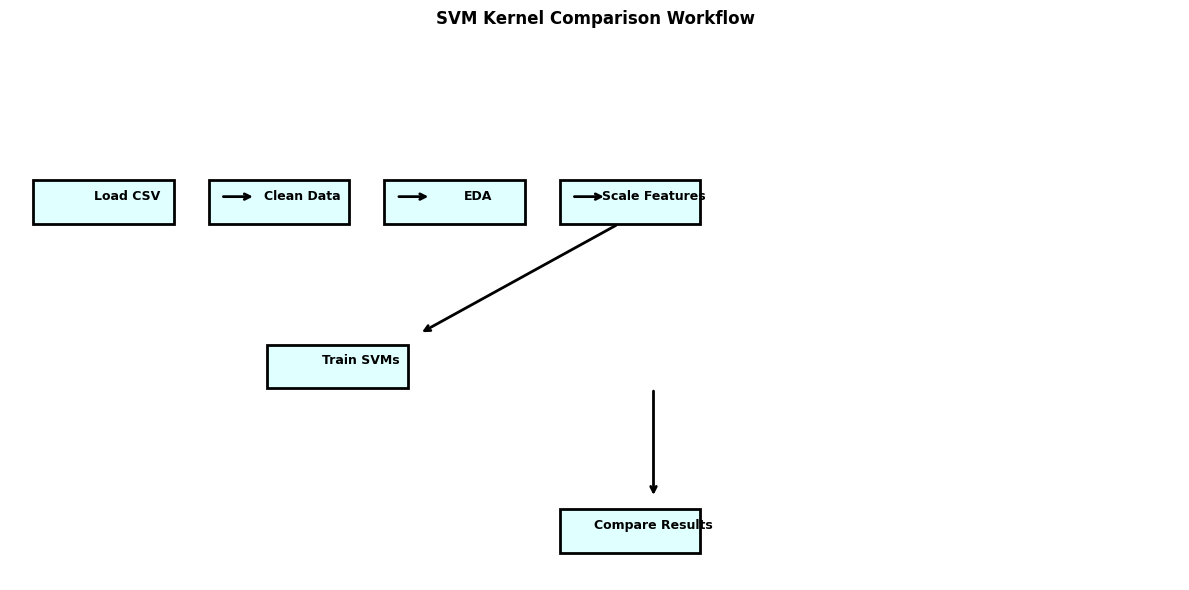

In [6]:
print('='*60)
print('WORKFLOW DIAGRAM')
print('='*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, 'Load CSV'),
    (0.25, 0.7, 'Clean Data'),
    (0.4, 0.7, 'EDA'),
    (0.55, 0.7, 'Scale Features'),
    (0.3, 0.4, 'Train SVMs'),
    (0.55, 0.1, 'Compare Results'),
]
for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x - 0.08, step_y - 0.05), 0.12, 0.08, facecolor='lightcyan', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)), ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('SVM Kernel Comparison Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Pseudocode

```
1. Load the student dataset
2. Clean the data
3. Explore the data visually
4. Scale the features
5. Split into train and test sets
6. Train a linear SVM model
7. Train an RBF SVM model
8. Predict on test data and calculate accuracy
9. Compare confusion matrices and accuracies
10. Save both models and the scaler
```

## 10. Train-Test Split and Model Training

Train both SVM models using the same split.

In [7]:
print('='*60)
print('TRAIN-TEST SPLIT AND MODEL TRAINING')
print('='*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

linear_model = SVC(kernel='linear')
rbf_model = SVC(kernel='rbf')

linear_model.fit(X_train, y_train)
rbf_model.fit(X_train, y_train)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size: {X_test.shape[0]} samples')
print(f'Linear SVM support vectors: {len(linear_model.support_vectors_)}')
print(f'RBF SVM support vectors: {len(rbf_model.support_vectors_)}')

TRAIN-TEST SPLIT AND MODEL TRAINING
Train size: 192 samples
Test size: 48 samples
Linear SVM support vectors: 46
RBF SVM support vectors: 65


## 11. Comparison of Results

Compare accuracy and confusion matrices for linear and RBF kernels.

In [8]:
print('='*60)
print('MODEL COMPARISON')
print('='*60)

linear_pred = linear_model.predict(X_test)
rbf_pred = rbf_model.predict(X_test)

linear_acc = accuracy_score(y_test, linear_pred)
rbf_acc = accuracy_score(y_test, rbf_pred)
linear_cm = confusion_matrix(y_test, linear_pred)
rbf_cm = confusion_matrix(y_test, rbf_pred)

print(f'Linear SVM Accuracy: {linear_acc:.4f}')
print(f'RBF SVM Accuracy:    {rbf_acc:.4f}')

print('\nLinear SVM Confusion Matrix:')
print(linear_cm)

print('\nRBF SVM Confusion Matrix:')
print(rbf_cm)

print('\nClassification Report - Linear SVM:')
print(classification_report(y_test, linear_pred, target_names=['Fail', 'Pass']))

print('\nClassification Report - RBF SVM:')
print(classification_report(y_test, rbf_pred, target_names=['Fail', 'Pass']))

MODEL COMPARISON
Linear SVM Accuracy: 0.8958
RBF SVM Accuracy:    0.8750

Linear SVM Confusion Matrix:
[[10  2]
 [ 3 33]]

RBF SVM Confusion Matrix:
[[ 9  3]
 [ 3 33]]

Classification Report - Linear SVM:
              precision    recall  f1-score   support

        Fail       0.77      0.83      0.80        12
        Pass       0.94      0.92      0.93        36

    accuracy                           0.90        48
   macro avg       0.86      0.88      0.86        48
weighted avg       0.90      0.90      0.90        48


Classification Report - RBF SVM:
              precision    recall  f1-score   support

        Fail       0.75      0.75      0.75        12
        Pass       0.92      0.92      0.92        36

    accuracy                           0.88        48
   macro avg       0.83      0.83      0.83        48
weighted avg       0.88      0.88      0.88        48



## 12. Obtained Output

Show the confusion matrices and final comparison.

OBTAINED OUTPUT - VISUALIZATIONS


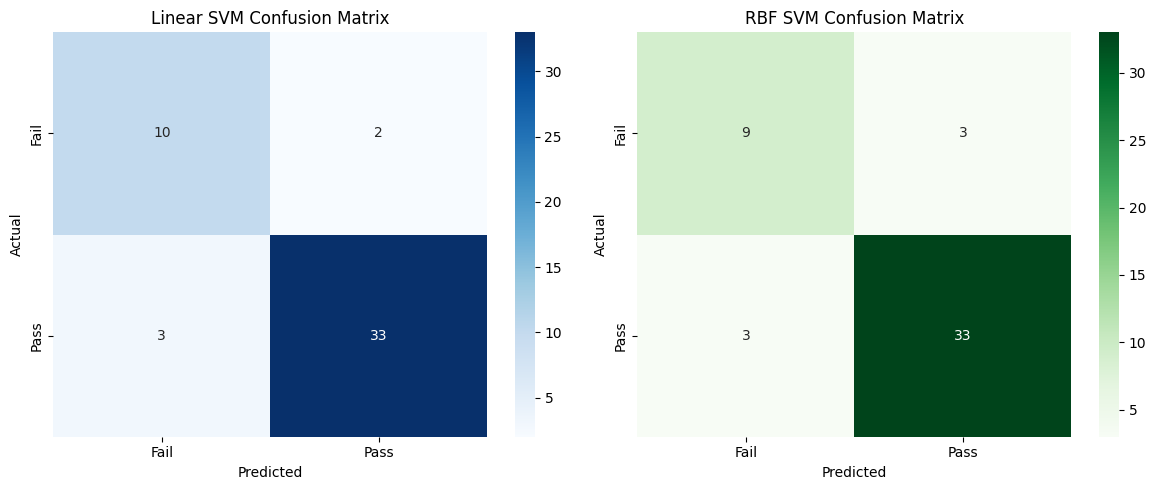

C:\Users\hardi\AppData\Local\Temp\ipykernel_31484\661345727.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kernel_names, y=accuracies, palette=['steelblue', 'seagreen'])


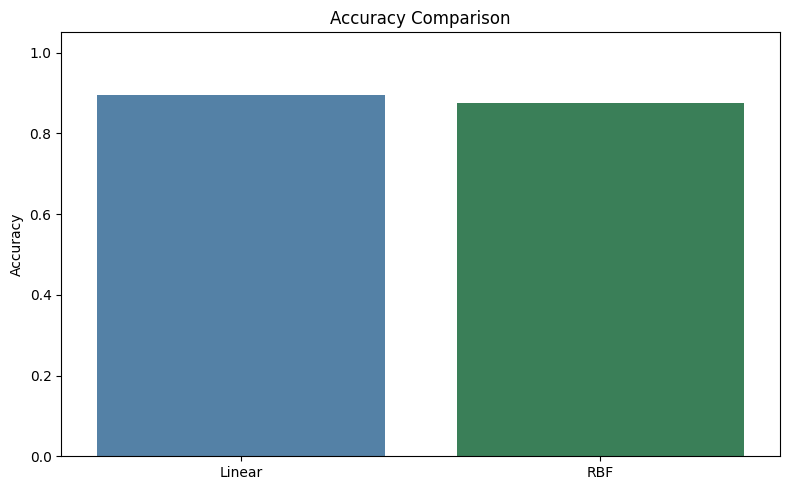


✓ Models and scaler saved successfully

Final Summary:
  Linear Accuracy: 0.8958
  RBF Accuracy:    0.8750
  Better Kernel:   Linear


In [9]:
print('='*60)
print('OBTAINED OUTPUT - VISUALIZATIONS')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(linear_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=axes[0])
axes[0].set_title('Linear SVM Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(rbf_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=axes[1])
axes[1].set_title('RBF SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
kernel_names = ['Linear', 'RBF']
accuracies = [linear_acc, rbf_acc]
sns.barplot(x=kernel_names, y=accuracies, palette=['steelblue', 'seagreen'])
plt.ylim(0, 1.05)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

joblib.dump(linear_model, '10_svm_linear_model.joblib')
joblib.dump(rbf_model, '10_svm_rbf_model.joblib')
joblib.dump(scaler, '10_svm_scaler.joblib')

print('\n✓ Models and scaler saved successfully')
print('\nFinal Summary:')
print(f'  Linear Accuracy: {linear_acc:.4f}')
print(f'  RBF Accuracy:    {rbf_acc:.4f}')
better = 'Linear' if linear_acc >= rbf_acc else 'RBF'
print(f'  Better Kernel:   {better}')